## Setup


In [1]:
%pip install numpy matplotlib pandas joblib



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
from joblib import Parallel, delayed


## Model functions


In [3]:
def sameShare(grid, row, col):
    cell = grid[row, col]
    around = []
    same = 0

    n = grid.shape[0]
    neighbours = []
    for row_index in [-1, 0, 1]:
        for col_index in [-1, 0, 1]:
            if row_index == 0 and col_index == 0:
                continue
            r2 = row + row_index
            c2 = col + col_index
            if r2 >= 0 and r2 < n and c2 >= 0 and c2 < n:
                neighbours.append(grid[r2, c2])

    for x in neighbours:
        if x == 0:
            continue
        around.append(x)
        if x == cell:
            same += 1

    if len(around) == 0:
        return 1.0
    else:
        return same / len(around)


def isHappyEnough(grid, row, col, tolerance):
    if grid[row, col] == 0:
        return True
    return sameShare(grid, row, col) >= tolerance


def getUnhappyCells(grid, tolerance):
    bad = []
    for row in range(grid.shape[0]):
        for col in range(grid.shape[1]):
            if grid[row, col] == 0:
                continue
            if isHappyEnough(grid, row, col, tolerance):
                continue
            bad.append((row, col))
    return bad


def makeRow(grid, tolerance, step, moves=None, stop_reason=np.nan):
    if moves is None:
        moves = {}

    sat = {}
    for group in [1, 2]:
        vals = []
        for row in range(grid.shape[0]):
            for col in range(grid.shape[1]):
                if grid[row, col] == group:
                    vals.append(isHappyEnough(grid, row, col, tolerance))
        sat[group] = np.mean(vals)

    seg = []
    for row in range(grid.shape[0]):
        for col in range(grid.shape[1]):
            if grid[row, col] != 0:
                seg.append(sameShare(grid, row, col))

    failed_mobility_a = moves.get("failed_mobility_a", 0)
    failed_mobility_b = moves.get("failed_mobility_b", 0)
    failed_destination_a = moves.get("failed_destination_a", 0)
    failed_destination_b = moves.get("failed_destination_b", 0)
    moves_a = moves.get("moves_a", 0)
    moves_b = moves.get("moves_b", 0)

    out = {}
    out["step"] = step
    out["segregation"] = np.mean(seg)
    out["unhappy_agents"] = len(getUnhappyCells(grid, tolerance))
    out["satisfaction_a"] = sat[1]
    out["satisfaction_b"] = sat[2]
    out["satisfaction_gap"] = sat[1] - sat[2]
    out["moves_a"] = moves_a
    out["moves_b"] = moves_b
    out["failed_mobility_a"] = failed_mobility_a
    out["failed_mobility_b"] = failed_mobility_b
    out["failed_destination_a"] = failed_destination_a
    out["failed_destination_b"] = failed_destination_b
    out["failed_moves_a"] = failed_mobility_a + failed_destination_a
    out["failed_moves_b"] = failed_mobility_b + failed_destination_b
    out["stop_reason"] = stop_reason
    return out


## Runs


In [4]:
def runModel(params, tolerance, mobility_b, seed=None):
    size = params["size"]
    cells_total = size * size
    agents_total = int(cells_total * params["density"])
    a_count = int(agents_total * params["group_share"])
    b_count = agents_total - a_count

    vals = np.array([1] * a_count + [2] * b_count + [0] * (cells_total - agents_total))

    rand = np.random.default_rng(seed)
    rand.shuffle(vals)
    grid = vals.reshape(size, size)

    hist = [makeRow(grid, tolerance, 0)]

    rand = np.random.default_rng(seed)
    for step in range(1, params["max_steps"] + 1):
        if hist[-1]["unhappy_agents"] == 0:
            hist[-1]["stop_reason"] = "equilibrium"
            break

        moves = {}
        moves["moves_a"] = 0
        moves["moves_b"] = 0
        moves["failed_mobility_a"] = 0
        moves["failed_mobility_b"] = 0
        moves["failed_destination_a"] = 0
        moves["failed_destination_b"] = 0

        cells = getUnhappyCells(grid, tolerance)
        rand.shuffle(cells)
        for row, col in cells:
            agent = grid[row, col]

            if agent == 0:
                continue
            if isHappyEnough(grid, row, col, tolerance):
                continue

            if agent == 1:
                mobility = params["mobility_a"]
            else:
                mobility = mobility_b

            if rand.random() > mobility:
                if agent == 1:
                    moves["failed_mobility_a"] += 1
                else:
                    moves["failed_mobility_b"] += 1
                continue

            empty_spots = []
            for r in range(grid.shape[0]):
                for c in range(grid.shape[1]):
                    if grid[r, c] == 0:
                        empty_spots.append((r, c))

            possible = []
            if agent == 1:
                possible = empty_spots
            elif params["mode"] == "anywhere":
                possible = empty_spots
            else:
                for r, c in empty_spots:
                    dist = max(abs(r - row), abs(c - col))
                    if dist <= params["b_radius"]:
                        possible.append((r, c))

            if len(possible) == 0:
                if agent == 1:
                    moves["failed_destination_a"] += 1
                else:
                    moves["failed_destination_b"] += 1
                continue

            new_row, new_col = possible[rand.integers(len(possible))]
            grid[new_row, new_col] = agent
            grid[row, col] = 0

            if agent == 1:
                moves["moves_a"] += 1
            else:
                moves["moves_b"] += 1

        hist.append(makeRow(grid, tolerance, step, moves))
        if hist[-1]["unhappy_agents"] == 0:
            hist[-1]["stop_reason"] = "equilibrium"
        elif moves["moves_a"] + moves["moves_b"] == 0:
            hist[-1]["stop_reason"] = "constrained"
        elif step == params["max_steps"]:
            hist[-1]["stop_reason"] = "max_steps"

        if pd.notna(hist[-1]["stop_reason"]):
            break

    return grid, pd.DataFrame(hist)


## Testing


In [5]:
params = {
    "size": 40,
    "density": 0.9,
    "group_share": 0.5,
    "mobility_a": 1.0,
    "max_steps": 300,
    "mode": "anywhere",
    "b_radius": 6,
    "mobility_b_values": (1.0, 0.8, 0.6, 0.4, 0.2),
    "tolerance_values": (0.3, 0.4, 0.5, 0.6),
    "repetitions": 50,
    "seed": 67,
    "n_jobs": -1,
}

final_grid, history = runModel(params, tolerance=0.5, mobility_b=0.4, seed=42)
# history.tail()


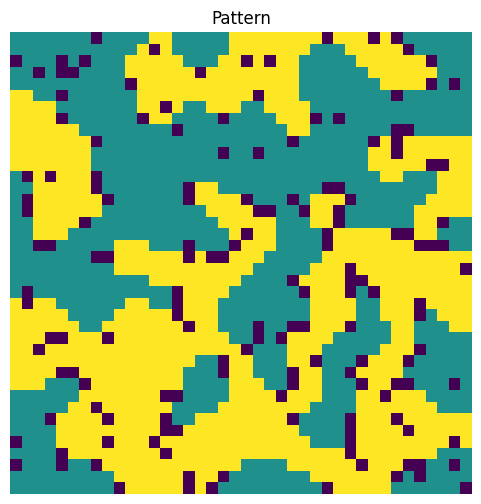

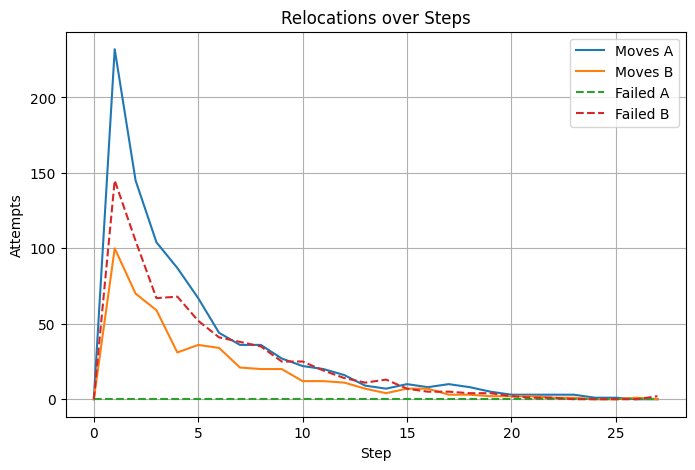

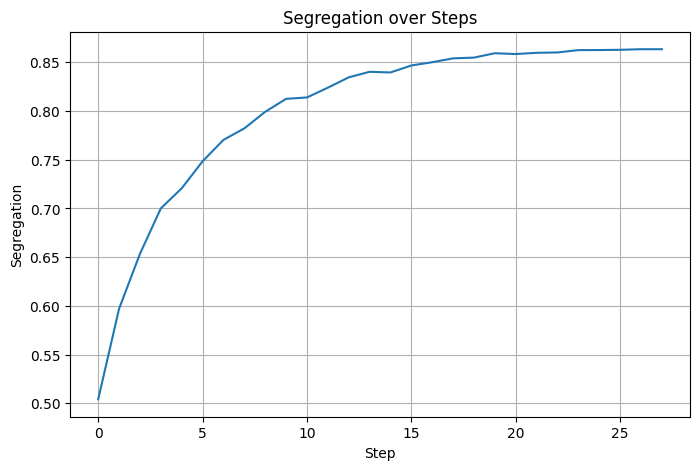

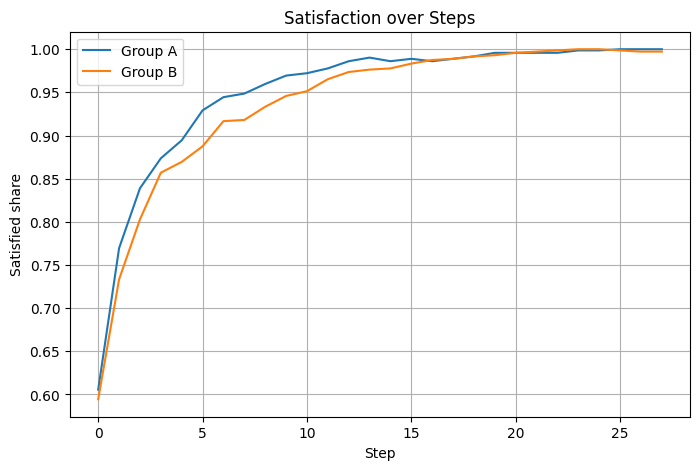

In [6]:
plt.figure(figsize=(6, 6))
plt.imshow(final_grid)
plt.title("Pattern")
plt.axis("off")
plt.savefig("../output/final_grid.png", bbox_inches="tight")
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(history["step"], history["moves_a"], label="Moves A")
plt.plot(history["step"], history["moves_b"], label="Moves B")
plt.plot(history["step"], history["failed_moves_a"], linestyle="--", label="Failed A")
plt.plot(history["step"], history["failed_moves_b"], linestyle="--", label="Failed B")
plt.xlabel("Step")
plt.ylabel("Attempts")
plt.title("Relocations over Steps")
plt.legend()
plt.grid(True)
plt.savefig("../output/relocations_over_time.png", bbox_inches="tight")
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(history["step"], history["segregation"])
plt.xlabel("Step")
plt.ylabel("Segregation")
plt.title("Segregation over Steps")
plt.grid(True)
plt.savefig("../output/segregation_over_time.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["step"], history["satisfaction_a"], label="Group A")
plt.plot(history["step"], history["satisfaction_b"], label="Group B")
plt.xlabel("Step")
plt.ylabel("Satisfied share")
plt.title("Satisfaction over Steps")
plt.legend()
plt.grid(True)
plt.savefig("../output/satisfaction_over_time.png", bbox_inches="tight")
plt.show()

## RQ1 - RQ5


In [7]:
def oneRun(task):
    i, tolerance, mobility_b, rep, stuff = task
    grid, hist = runModel(stuff, tolerance, mobility_b, stuff["seed"] + i)
    last = hist.iloc[-1]

    row = {}
    row["mode"] = stuff["mode"]
    row["tolerance"] = tolerance
    row["final_unhappy_agents"] = last["unhappy_agents"]
    row["mobility_b"] = mobility_b
    row["mobility_gap"] = stuff["mobility_a"] - mobility_b
    row["final_segregation"] = last["segregation"]
    row["satisfaction_gap"] = last["satisfaction_gap"]
    row["total_moves_a"] = hist["moves_a"].sum()
    row["total_moves_b"] = hist["moves_b"].sum()
    row["total_failed_mobility_b"] = hist["failed_mobility_b"].sum()
    row["total_failed_destination_b"] = hist["failed_destination_b"].sum()
    row["total_failed_moves_a"] = hist["failed_moves_a"].sum()
    row["total_failed_moves_b"] = hist["failed_moves_b"].sum()
    row["steps_until_stop"] = int(last["step"])
    if last["stop_reason"] == "equilibrium":
        row["steps_to_equilibrium"] = int(last["step"])
    else:
        row["steps_to_equilibrium"] = np.nan
    row["stop_reason"] = last["stop_reason"]
    row["equilibrium_reached"] = last["stop_reason"] == "equilibrium"
    return row


def runAll(params):
    tasks = []
    i = 0
    for tolerance in params["tolerance_values"]:
        for mobility_b in params["mobility_b_values"]:
            for rep in range(params["repetitions"]):
                tasks.append((i, tolerance, mobility_b, rep, params))
                i += 1

    jobs = []
    for task in tasks:
        jobs.append(delayed(oneRun)(task))
    ans = Parallel(n_jobs=params["n_jobs"], verbose=10)(jobs)

    return pd.DataFrame(ans)


In [8]:
params = {
    "size": 40,
    "density": 0.9,
    "group_share": 0.5,
    "mobility_a": 1.0,
    "max_steps": 300,
    "mode": "anywhere",
    "b_radius": 6,
    "mobility_b_values": (1.0, 0.8, 0.6, 0.4, 0.2),
    "tolerance_values": (0.3, 0.4, 0.5, 0.6),
    "repetitions": 50,
    "seed": 67,
    "n_jobs": -1,
}

results = runAll(params)
# results.head()

data = results.groupby(["tolerance", "mobility_b"]).agg(
    mean_final_segregation=("final_segregation", "mean"),
    mean_steps_until_stop=("steps_until_stop", "mean"),
    mean_steps_to_equilibrium=("steps_to_equilibrium", "mean"),
    equilibrium_rate=("equilibrium_reached", "mean"),
    mean_final_unhappy_agents=("final_unhappy_agents", "mean"),
    mean_satisfaction_gap=("satisfaction_gap", "mean"),
    mean_moves_b=("total_moves_b", "mean"),
    mean_failed_moves_b=("total_failed_moves_b", "mean"),
    mean_failed_mobility_b=("total_failed_mobility_b", "mean"),
    mean_failed_destination_b=("total_failed_destination_b", "mean"),
).reset_index()
data.head()


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done    9 out of 1000 | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done   18 out of 1000 | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done   29 out of 1000 | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done   40 out of 1000 | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done   53 out of 1000 | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done   66 out of 1000 | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done   81 out of 1000 | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done   96 out of 1000 | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done  113 out of 1000 | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done  130 out of 1000 | elapsed:    6.6s
[Parallel(n_jobs=-1)]: Done  149 out of 1000 | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done  168 out of 1000 | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done  189 out of 1000 | elapsed:    9.6s
[Parallel(n_jobs=-1)]: Done  210 out of 1000 | elapsed:   10.8s
[Parallel(n_jobs=-1)]: Done

,tolerance,mobility_b,mean_final_segregation,mean_steps_until_stop,mean_steps_to_equilibrium,equilibrium_rate,mean_final_unhappy_agents,mean_satisfaction_gap,mean_moves_b,mean_failed_moves_b,mean_failed_mobility_b,mean_failed_destination_b
0,0.3,0.2,0.746689,32.30,NaN,0.0,8.44,0.011722,246.76,987.66,987.66,0.0
1,0.3,0.4,0.749967,23.08,22.100000,0.2,2.16,0.003000,262.62,394.56,394.56,0.0
2,0.3,0.6,0.753212,18.82,18.600000,0.5,0.86,0.001194,282.96,193.96,193.96,0.0
3,0.3,0.8,0.757292,15.30,14.914286,0.7,0.30,0.000417,287.98,72.88,72.88,0.0
4,0.3,1.0,0.751662,14.02,14.020000,1.0,0.00,0.000000,285.44,0.00,0.00,0.0


## RQ Helpers


In [9]:
def compareMinMaxMobility(data, metrics):
    low = data["mobility_b"].min()
    high = data["mobility_b"].max()
    row = {}
    row["low_mobility_b"] = low
    row["high_mobility_b"] = high

    low_bits = data[data["mobility_b"] == low]
    high_bits = data[data["mobility_b"] == high]
    low_mean = low_bits[metrics].mean(numeric_only=True)
    high_mean = high_bits[metrics].mean(numeric_only=True)

    for metric in metrics:
        row[f"{metric}_low"] = low_mean[metric]
        row[f"{metric}_high"] = high_mean[metric]
        row[f"{metric}_diff"] = low_mean[metric] - high_mean[metric]
    return pd.DataFrame([row])


def compareAllMobility(data, metrics, by):
    rows = []
    for key, group in data.groupby(by, dropna=False):
        if isinstance(key, tuple):
            vals = key
        else:
            vals = (key,)

        row = {}
        for i in range(len(by)):
            row[by[i]] = vals[i]

        means = group.groupby("mobility_gap")[metrics].mean(numeric_only=True).reset_index()
        for metric in metrics:
            clean = means[["mobility_gap", metric]].dropna()
            if clean["mobility_gap"].nunique() > 1:
                fit = np.polyfit(clean["mobility_gap"], clean[metric], 1)
                row[f"{metric}_slope"] = fit[0]
            else:
                row[f"{metric}_slope"] = np.nan
        rows.append(row)

    return pd.DataFrame(rows)


## RQ1


<Figure size 800x500 with 0 Axes>

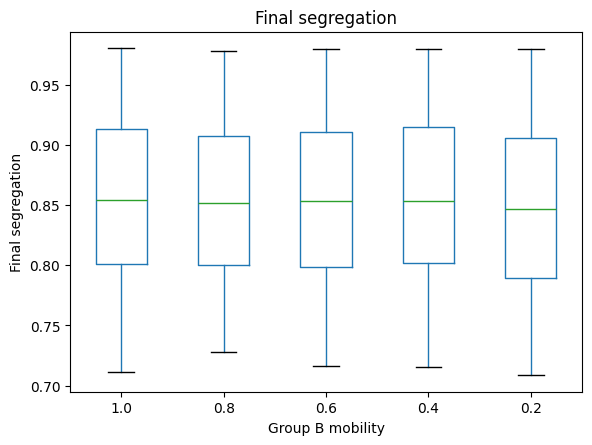

,low_mobility_b,high_mobility_b,final_segregation_low,final_segregation_high,final_segregation_diff
0,0.2,1.0,0.852215,0.856439,-0.004224


In [10]:
rq1 = compareMinMaxMobility(results, ["final_segregation"])

plt.figure(figsize=(8, 5))
results.boxplot(column="final_segregation", by="mobility_b", grid=False)
plt.xlabel("Group B mobility")
plt.ylabel("Final segregation")
plt.title("Final segregation")
plt.suptitle("")
plt.gca().invert_xaxis()
plt.savefig("../output/final_segregation_by_mobility.png", bbox_inches="tight")
plt.show()

rq1

## RQ2


<Figure size 800x500 with 0 Axes>

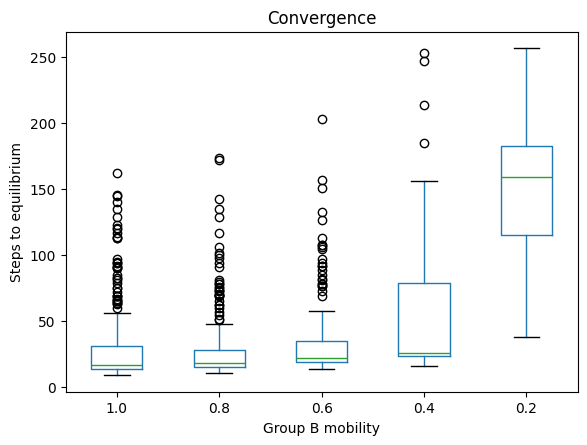

,low_mobility_b,high_mobility_b,steps_to_equilibrium_low,steps_to_equilibrium_high,steps_to_equilibrium_diff,steps_until_stop_low,steps_until_stop_high,steps_until_stop_diff,equilibrium_reached_low,equilibrium_reached_high,equilibrium_reached_diff
0,0.2,1.0,149.4,33.105,116.295,63.565,33.105,30.46,0.075,1.0,-0.925


In [11]:
rq2 = compareMinMaxMobility(results, ["steps_to_equilibrium", "steps_until_stop", "equilibrium_reached"])

plt.figure(figsize=(8, 5))
results.boxplot(column="steps_to_equilibrium", by="mobility_b", grid=False)
plt.xlabel("Group B mobility")
plt.ylabel("Steps to equilibrium")
plt.title("Convergence")
plt.suptitle("")
plt.gca().invert_xaxis()
plt.savefig("../output/steps_to_equilibrium_by_mobility.png", bbox_inches="tight")
plt.show()

rq2

## RQ3


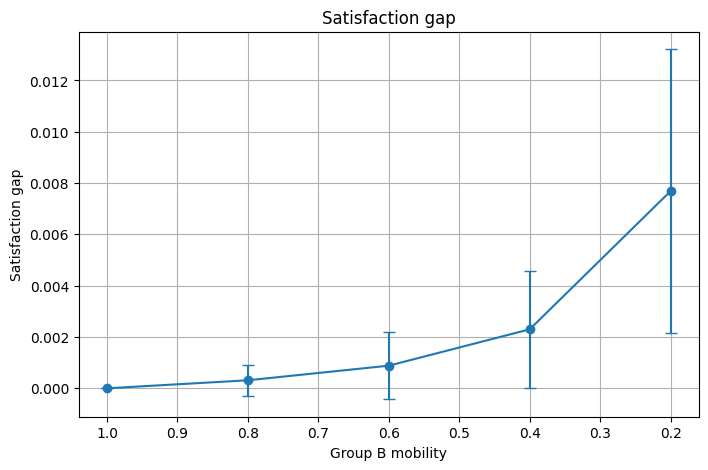

,low_mobility_b,high_mobility_b,satisfaction_gap_low,satisfaction_gap_high,satisfaction_gap_diff
0,0.2,1.0,0.007687,0.0,0.007687


In [12]:
rq3 = compareMinMaxMobility(results, ["satisfaction_gap"])

plot_data = results.groupby("mobility_b")["satisfaction_gap"].agg(["mean", "std"]).reset_index()
plt.figure(figsize=(8, 5))
plt.errorbar(plot_data["mobility_b"], plot_data["mean"], yerr=plot_data["std"], marker="o", capsize=4)
plt.xlabel("Group B mobility")
plt.ylabel("Satisfaction gap")
plt.title("Satisfaction gap")
plt.gca().invert_xaxis()
plt.grid(True)
plt.savefig("../output/satisfaction_gap_by_mobility.png", bbox_inches="tight")
plt.show()

rq3

## RQ4


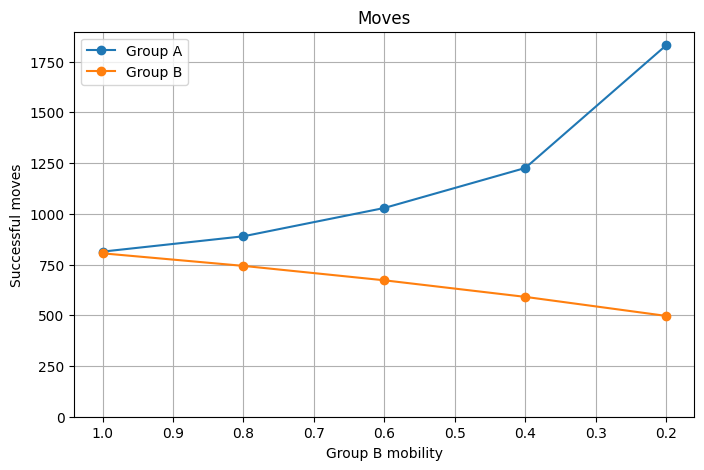

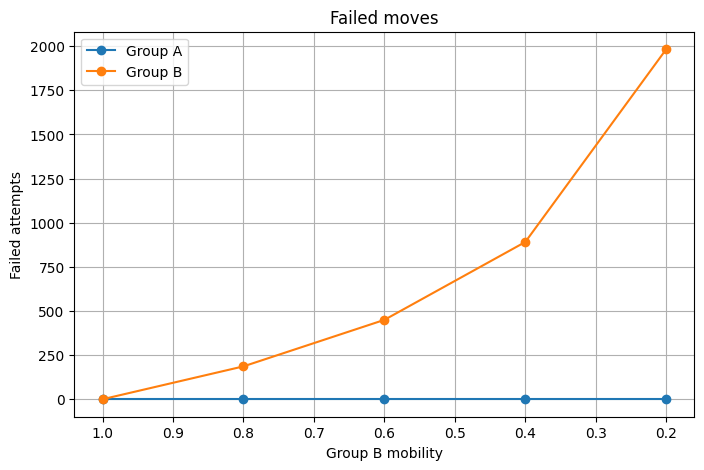

,low_mobility_b,high_mobility_b,total_moves_b_low,total_moves_b_high,total_moves_b_diff,total_failed_moves_b_low,total_failed_moves_b_high,total_failed_moves_b_diff,total_failed_mobility_b_low,total_failed_mobility_b_high,total_failed_mobility_b_diff,total_failed_destination_b_low,total_failed_destination_b_high,total_failed_destination_b_diff
0,0.2,1.0,496.705,805.18,-308.475,1982.94,0.0,1982.94,1982.94,0.0,1982.94,0.0,0.0,0.0


In [13]:
rq4 = compareMinMaxMobility(results, ["total_moves_b", "total_failed_moves_b", "total_failed_mobility_b", "total_failed_destination_b"])

plot_data = results.groupby("mobility_b")[["total_moves_a", "total_moves_b"]].mean().reset_index()
plt.figure(figsize=(8, 5))
plt.plot(plot_data["mobility_b"], plot_data["total_moves_a"], marker="o", label="Group A")
plt.plot(plot_data["mobility_b"], plot_data["total_moves_b"], marker="o", label="Group B")
plt.xlabel("Group B mobility")
plt.ylabel("Successful moves")
plt.title("Moves")
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)
plt.savefig("../output/moves_by_mobility.png", bbox_inches="tight")
plt.show()

plot_data = results.groupby("mobility_b")[["total_failed_moves_a", "total_failed_moves_b"]].mean().reset_index()
plt.figure(figsize=(8, 5))
plt.plot(plot_data["mobility_b"], plot_data["total_failed_moves_a"], marker="o", label="Group A")
plt.plot(plot_data["mobility_b"], plot_data["total_failed_moves_b"], marker="o", label="Group B")
plt.xlabel("Group B mobility")
plt.ylabel("Failed attempts")
plt.title("Failed moves")
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True)
plt.savefig("../output/failed_moves_by_mobility.png", bbox_inches="tight")
plt.show()

rq4

## RQ5


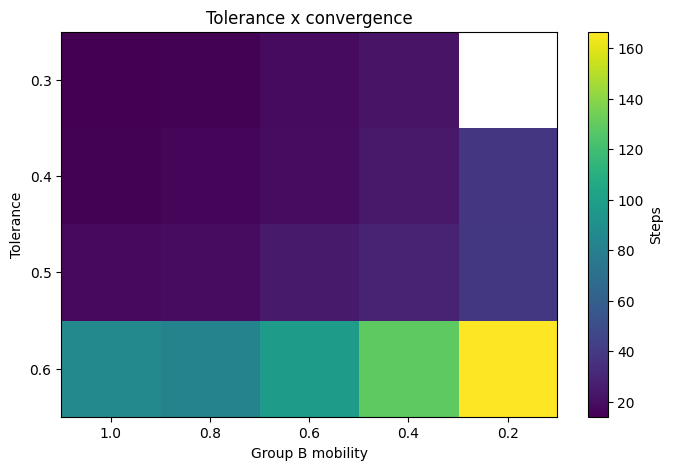

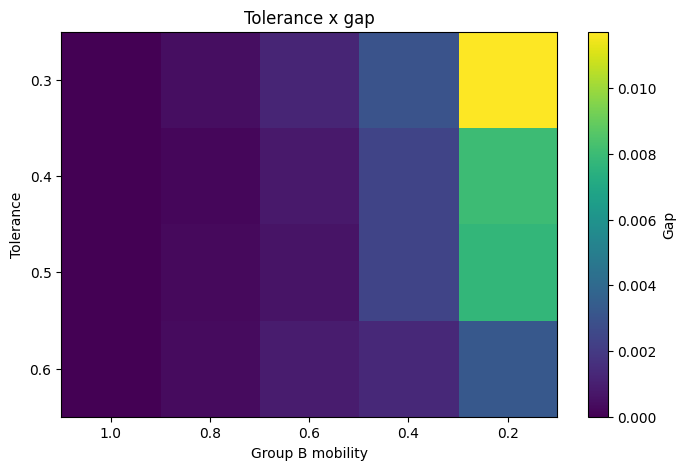

,tolerance,steps_until_stop_slope,equilibrium_reached_slope,satisfaction_gap_slope
0,0.3,22.17,-1.25,0.013014
1,0.4,20.14,-1.27,0.009153
2,0.5,22.89,-1.25,0.008819
3,0.6,82.57,-0.94,0.003736


In [14]:
rq5 = compareAllMobility(results, ["steps_until_stop", "equilibrium_reached", "satisfaction_gap"], by=["tolerance"])

heatmap_data = results.groupby(["tolerance", "mobility_b"])["steps_to_equilibrium"].mean().unstack()
plt.figure(figsize=(8, 5))
plt.imshow(heatmap_data, aspect="auto")
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.xlabel("Group B mobility")
plt.ylabel("Tolerance")
plt.title("Tolerance x convergence")
plt.colorbar(label="Steps")
plt.gca().invert_xaxis()
plt.savefig("../output/tolerance_convergence_heatmap.png", bbox_inches="tight")
plt.show()

heatmap_data = results.groupby(["tolerance", "mobility_b"])["satisfaction_gap"].mean().unstack()
plt.figure(figsize=(8, 5))
plt.imshow(heatmap_data, aspect="auto")
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.xlabel("Group B mobility")
plt.ylabel("Tolerance")
plt.title("Tolerance x gap")
plt.colorbar(label="Gap")
plt.gca().invert_xaxis()
plt.savefig("../output/tolerance_gap_heatmap.png", bbox_inches="tight")
plt.show()

rq5

## RQ6


In [15]:

params = {
    "size": 40,
    "density": 0.9,
    "group_share": 0.5,
    "mobility_a": 1.0,
    "max_steps": 300,
    "mode": "radius",
    "b_radius": 6,
    "mobility_b_values": (1.0, 0.8, 0.6, 0.4, 0.2),
    "tolerance_values": (0.3, 0.4, 0.5, 0.6),
    "repetitions": 50,
    "seed": 67,
    "n_jobs": -1,
}

radius_results = runAll(params)
# radius_results.head()

combined_results = pd.concat([results, radius_results], ignore_index=True)
combined = combined_results.groupby(["mode", "mobility_b"]).agg(
    mean_final_segregation=("final_segregation", "mean"),
    mean_steps_until_stop=("steps_until_stop", "mean"),
    mean_steps_to_equilibrium=("steps_to_equilibrium", "mean"),
    equilibrium_rate=("equilibrium_reached", "mean"),
    mean_satisfaction_gap=("satisfaction_gap", "mean"),
    mean_failed_moves_b=("total_failed_moves_b", "mean"),
).reset_index()
combined.head()


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done    9 out of 1000 | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done   18 out of 1000 | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done   29 out of 1000 | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done   40 out of 1000 | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done   53 out of 1000 | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done   66 out of 1000 | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done   81 out of 1000 | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done   96 out of 1000 | elapsed:    8.2s
[Parallel(n_jobs=-1)]: Done  113 out of 1000 | elapsed:   10.2s
[Parallel(n_jobs=-1)]: Done  130 out of 1000 | elapsed:   11.5s
[Parallel(n_jobs=-1)]: Done  149 out of 1000 | elapsed:   13.1s
[Parallel(n_jobs=-1)]: Done  168 out of 1000 | elapsed:   14.9s
[Parallel(n_jobs=-1)]: Done  189 out of 1000 | elapsed:   16.9s
[Parallel(n_jobs=-1)]: Done  210 out of 1000 | elapsed:   18.5s
[Parallel(n_jobs=-1)]: Done

,mode,mobility_b,mean_final_segregation,mean_steps_until_stop,mean_steps_to_equilibrium,equilibrium_rate,mean_satisfaction_gap,mean_failed_moves_b
0,anywhere,0.2,0.852215,63.565,149.400000,0.075,0.007687,1982.940
1,anywhere,0.4,0.856525,47.345,59.054545,0.275,0.002299,890.835
2,anywhere,0.6,0.857028,39.200,39.756757,0.555,0.000882,449.615
3,anywhere,0.8,0.858508,34.380,32.967949,0.780,0.000312,186.200
4,anywhere,1.0,0.856439,33.105,33.105000,1.000,0.000000,0.000


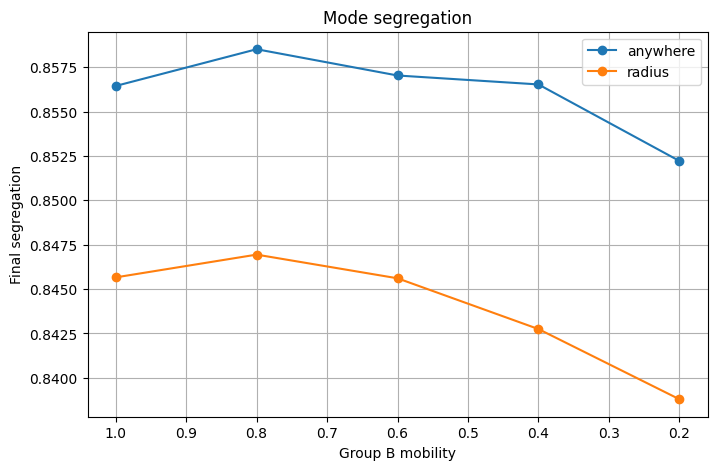

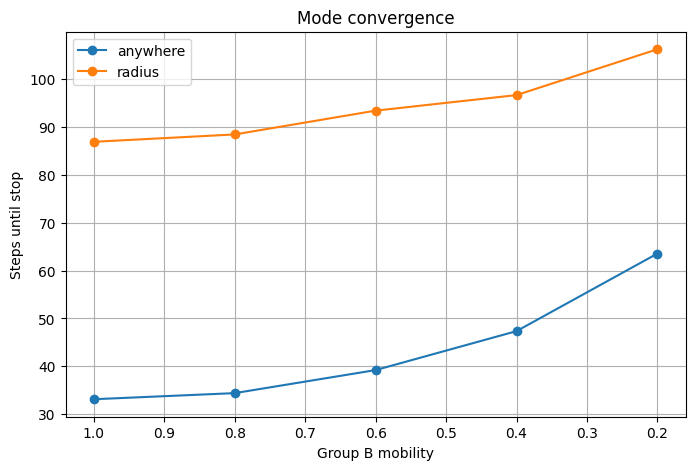

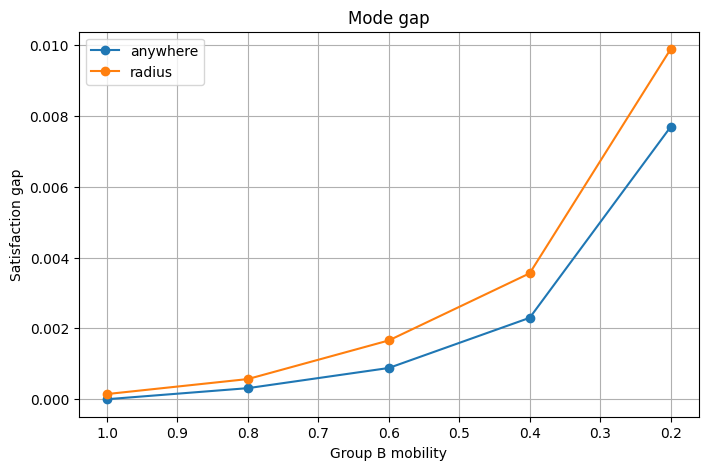

,mode,steps_until_stop_slope,equilibrium_reached_slope,satisfaction_gap_slope
0,anywhere,36.9425,-1.1775,0.008681
1,radius,23.4675,-1.0300,0.011229


In [16]:
rq6 = compareAllMobility(combined_results, ["steps_until_stop", "equilibrium_reached", "satisfaction_gap"], by=["mode"])

plt.figure(figsize=(8, 5))
for mode, subset in combined.groupby("mode"):
    plt.plot(subset["mobility_b"], subset["mean_final_segregation"], marker="o", label=mode)
plt.xlabel("Group B mobility")
plt.ylabel("Final segregation")
plt.title("Mode segregation")
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True)
plt.savefig("../output/mode_final_segregation_by_mobility.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
for mode, subset in combined.groupby("mode"):
    plt.plot(subset["mobility_b"], subset["mean_steps_until_stop"], marker="o", label=mode)
plt.xlabel("Group B mobility")
plt.ylabel("Steps until stop")
plt.title("Mode convergence")
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True)
plt.savefig("../output/mode_steps_until_stop_by_mobility.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
for mode, subset in combined.groupby("mode"):
    plt.plot(subset["mobility_b"], subset["mean_satisfaction_gap"], marker="o", label=mode)
plt.xlabel("Group B mobility")
plt.ylabel("Satisfaction gap")
plt.title("Mode gap")
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True)
plt.savefig("../output/mode_satisfaction_gap_by_mobility.png", bbox_inches="tight")
plt.show()

rq6